# AutoML Study Visualization
Pair B notebook. Run after `run_and_record()` has produced `studies/csai415-d1-knn.db` and `configs/winning_runcard.yaml`.

Loads the SQLite study + runcard, then makes the plots that go into the D1 report.

In [1]:
from pathlib import Path
import yaml
import optuna
import matplotlib.pyplot as plt
import pandas as pd

STUDY_NAME = "csai415-d1-knn"
STUDY_DB = Path("../studies/csai415-d1-knn.db")
RUNCARD = Path("../configs/winning_runcard.yaml")
REPORTS = Path("../reports")
REPORTS.mkdir(parents=True, exist_ok=True)

study = optuna.load_study(study_name=STUDY_NAME, storage=f"sqlite:///{STUDY_DB.as_posix()}")
runcard = yaml.safe_load(RUNCARD.read_text())
print(f"Loaded study: {len(study.trials)} trials")
print(f"Winner: NDCG@5 = {study.best_value:.4f}")
print(f"Winning params: {study.best_params}")

Loaded study: 80 trials
Winner: NDCG@5 = 0.7166
Winning params: {'metric': 'l2', 'svd_dim': None, 'normalize': False, 'hybrid_weight': 0.8102310529569093, 'candidate_k': 24}


## 1. Optimization history
Running best NDCG@5 across trials. If the curve is still climbing at trial 80, the study should be run longer.

C:\Users\waska\AppData\Local\Temp\ipykernel_26876\3101727276.py:1: ExperimentalWarning: plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  ax = optuna.visualization.matplotlib.plot_optimization_history(study)


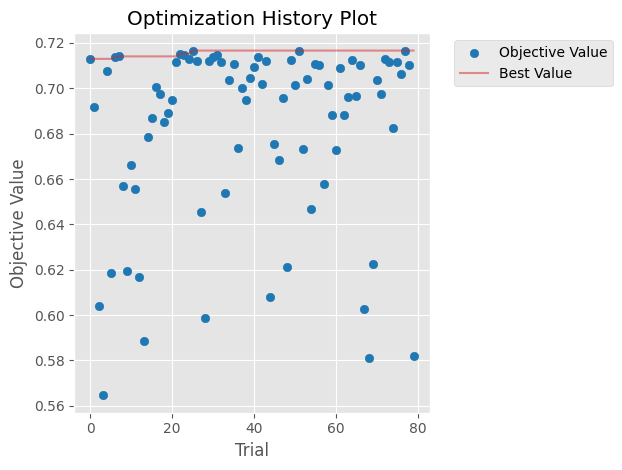

In [2]:
ax = optuna.visualization.matplotlib.plot_optimization_history(study)
plt.tight_layout()
plt.savefig(REPORTS / "optimization_history.png", dpi=120, bbox_inches="tight")
plt.show()

## 2. Parameter importances
Which hyperparameter mattered most? Higher = more influence on NDCG@5.

C:\Users\waska\AppData\Local\Temp\ipykernel_26876\2950461079.py:1: ExperimentalWarning: plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  ax = optuna.visualization.matplotlib.plot_param_importances(study)


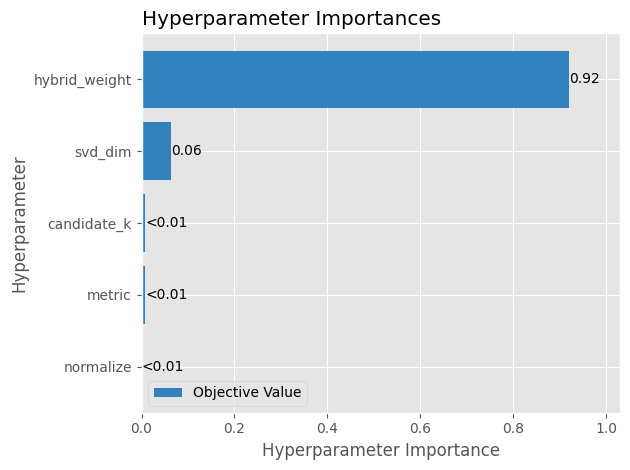

In [3]:
ax = optuna.visualization.matplotlib.plot_param_importances(study)
plt.tight_layout()
plt.savefig(REPORTS / "param_importances.png", dpi=120, bbox_inches="tight")
plt.show()

## 3. Winner vs baselines (holdout NDCG@5)
The D1 narrative figure: hybrid retrieval (AutoML winner) beats both lone-backend baselines AND the un-tuned default.

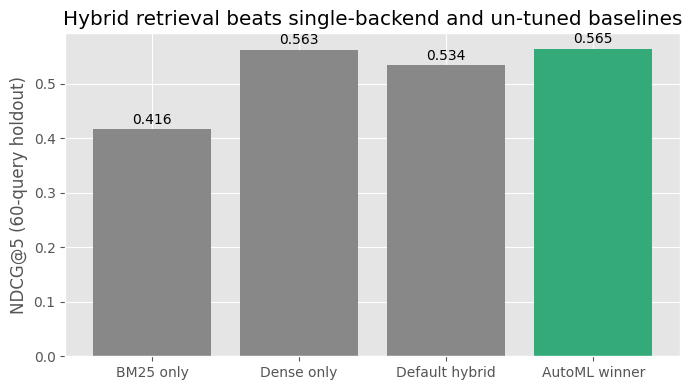

In [4]:
m = runcard["metrics"]
b = m["baselines_holdout"]
w = m["winner_holdout"]

labels = ["BM25 only", "Dense only", "Default hybrid", "AutoML winner"]
ndcg = [b["bm25_only"]["ndcg5"], b["dense_only"]["ndcg5"], b["default_hybrid"]["ndcg5"], w["ndcg5"]]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(labels, ndcg, color=["#888", "#888", "#888", "#3a7"])
ax.set_ylabel("NDCG@5 (60-query holdout)")
ax.set_title("Hybrid retrieval beats single-backend and un-tuned baselines")
for bar, val in zip(bars, ndcg):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.01, f"{val:.3f}", ha="center", fontsize=10)
plt.tight_layout()
plt.savefig(REPORTS / "winner_vs_baselines.png", dpi=120, bbox_inches="tight")
plt.show()

## 4. Summary table for the report

In [5]:
table = pd.DataFrame({
    "config": ["BM25 only", "Dense only", "Default hybrid", "AutoML winner"],
    "NDCG@5": [b["bm25_only"]["ndcg5"], b["dense_only"]["ndcg5"], b["default_hybrid"]["ndcg5"], w["ndcg5"]],
    "Recall@5": [b["bm25_only"]["recall5"], b["dense_only"]["recall5"], b["default_hybrid"]["recall5"], w["recall5"]],
    "p95 latency (ms)": [b["bm25_only"]["p95_latency_ms"], b["dense_only"]["p95_latency_ms"], b["default_hybrid"]["p95_latency_ms"], w["p95_latency_ms"]],
})
table.to_csv(REPORTS / "winner_vs_baselines.csv", index=False)
print(table.to_string(index=False))

        config   NDCG@5  Recall@5  p95 latency (ms)
     BM25 only 0.416323  0.465000        103.064835
    Dense only 0.563043  0.648889         97.385860
Default hybrid 0.534177  0.593333         92.025545
 AutoML winner 0.564623  0.632222        112.037775


## 5. Tune vs holdout — overfitting check
Comparing the winner's NDCG@5 on the 240 tune queries vs the 60-query holdout. A gap of more than ~5 points suggests TPE overfit to the eval set.

In [6]:
tune = m["winner_tune"]
print(f"Tune NDCG@5:    {tune['ndcg5']:.4f}")
print(f"Holdout NDCG@5: {w['ndcg5']:.4f}")
gap = tune["ndcg5"] - w["ndcg5"]
print(f"Gap: {gap:+.4f} ({'overfit signal' if gap > 0.05 else 'no overfit signal'})")

Tune NDCG@5:    0.7166
Holdout NDCG@5: 0.5646
Gap: +0.1520 (overfit signal)
